# Importing The Important Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Understanding The Features
- age -- Age of the person
- sex -- Male/Female
- bmi -- Body Mass Index
- children -- Number of children/dependents
- smoker -- Yes/No
- region -- US region
- charges -- Medical insurance cost

# Reading The Dataset

In [ ]:
files.upload()
df = pd.read_csv('insurance.csv')

Saving insurance.csv to insurance (5).csv


# EDA

## Basic EDA
- How many rows and columns are in the dataset?
- What are the data types of each feature?
- Are there any missing values?
- Are there any duplicated rows?
- What are the unique values of each categorical feature?
- What are the minimum, maximum, mean, and median values of the numerical features?
- What is the distribution of charges?

In [ ]:
df.shape

(1338, 7)

In [ ]:
print(df.dtypes)

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.to_list()
categorical_features = df.select_dtypes(include='object').columns.to_list()
print(numerical_features)
print(categorical_features)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
['age', 'bmi', 'children', 'charges']
['sex', 'smoker', 'region']


In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
for feature in categorical_features:
  print(feature, ':')
  print(df[feature].unique())

sex :
['female' 'male']
smoker :
['yes' 'no']
region :
['southwest' 'southeast' 'northwest' 'northeast']


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


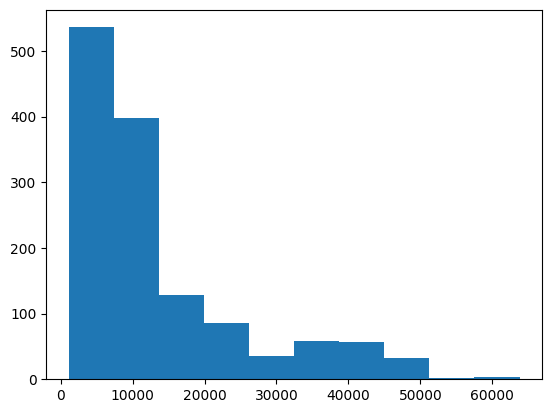

1.5158796580240388


In [ ]:
plt.hist(df['charges'])
plt.show()
print(df['charges'].skew())

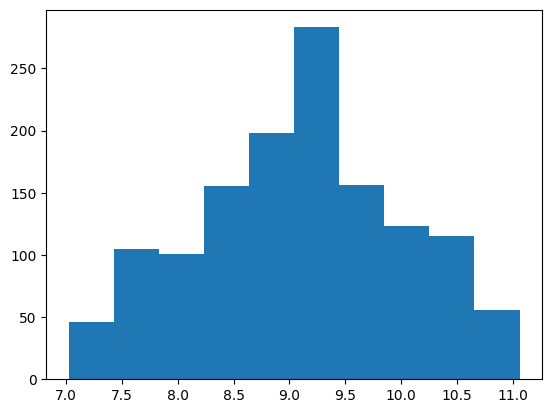

In [ ]:
plt.hist(np.log(df['charges']))
plt.show()

## Univariate Analysis
- What is the age distribution of the customers?
- What is the BMI distribution?
- How many customers are smokers vs. non-smokers?
- How are customers distributed across the different regions?
- How many children does each customer have?
- Is the charges distribution symmetric or skewed?

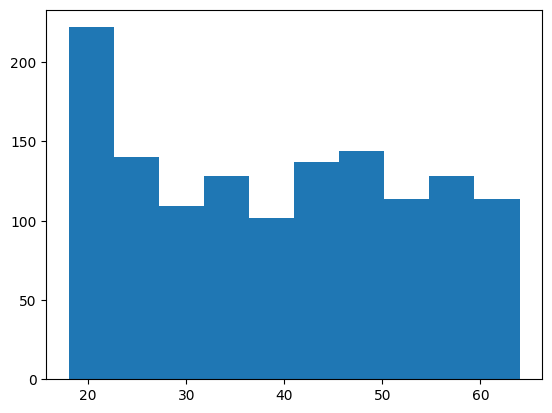

0.05567251565299186


In [ ]:
plt.hist(df['age'])
plt.show()
print(df['age'].skew())

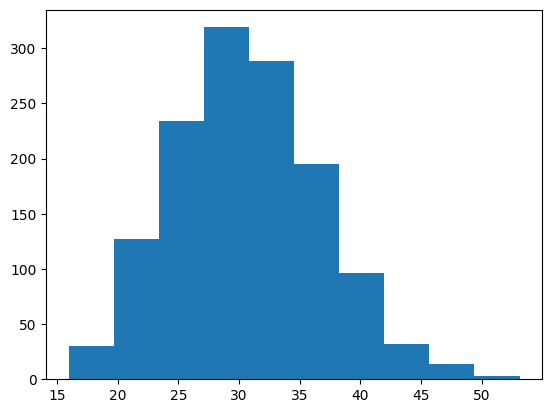

0.2840471105987448


In [ ]:
plt.hist(df['bmi'])
plt.show()
print(df['bmi'].skew())

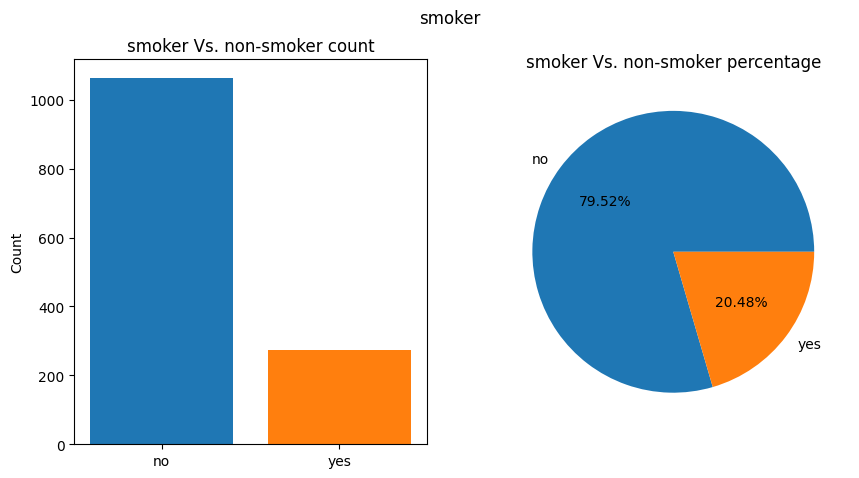

In [ ]:
smoker = df['smoker'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].bar(smoker.index, smoker, color=['tab:blue', 'tab:orange'])
axes[0].set_title('smoker Vs. non-smoker count')
axes[0].set_ylabel('Count')
axes[1].pie(smoker, autopct='%0.2f%%',labels = smoker.index)
axes[1].set_title('smoker Vs. non-smoker percentage')
fig.suptitle('smoker')
plt.show()

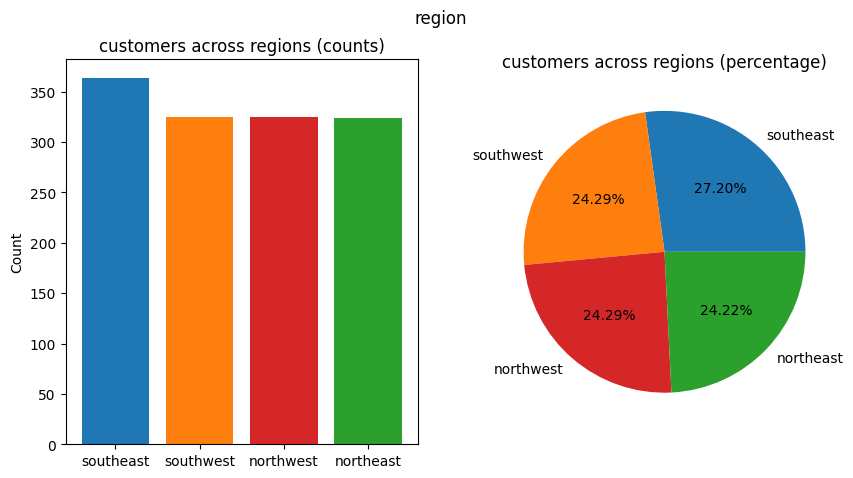

In [ ]:
region = df['region'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
colors = ['tab:blue', 'tab:orange', 'tab:red', 'tab:green']
axes[0].bar(region.index, region, color=colors)
axes[0].set_title('customers across regions (counts)')
axes[0].set_ylabel('Count')
axes[1].pie(region, autopct='%0.2f%%',labels = region.index, colors=colors)
axes[1].set_title('customers across regions (percentage)')
fig.suptitle('region')
plt.show()

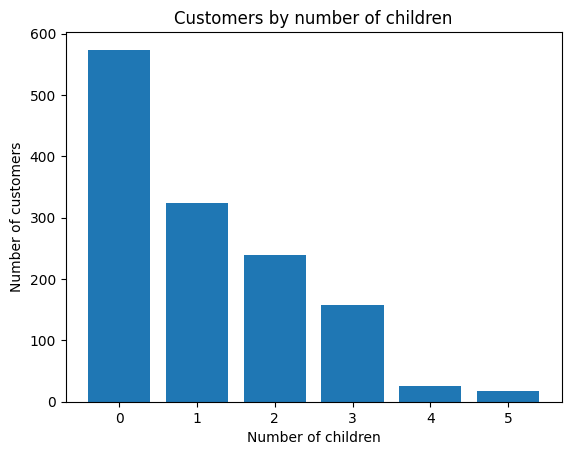

In [ ]:
children = df['children'].value_counts().sort_index()
plt.bar(children.index, children)
plt.xlabel('Number of children')
plt.ylabel('Number of customers')
plt.title('Customers by number of children')
plt.show()

In [ ]:
print('right skewed')

right skewed


## Relationship Analysis
- Does age have a relationship with medical charges?
- Does BMI have a relationship with medical charges?
- Do smokers have higher medical charges than non-smokers?
- Are medical charges different between males and females?
- Does the number of children affect medical charges?
- Are medical charges different across regions?
- Does age differ between smokers and non-smokers?
- Is BMI different between smokers and non-smokers?

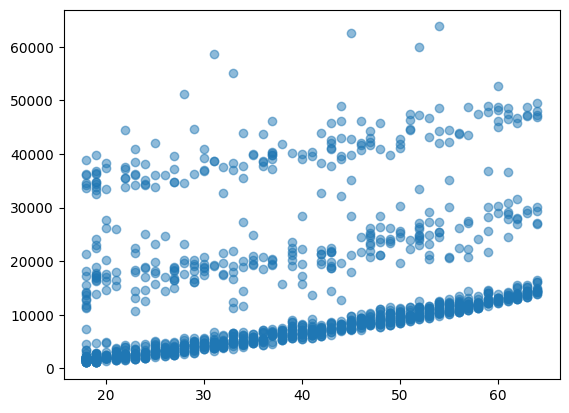

There is a weak overall relationship between age and charges (r = 0.30)


In [ ]:
plt.scatter(df['age'], df['charges'], alpha=0.5)
plt.show()
age_charges_corr = df['age'].corr(df['charges'])
print(f"There is a weak overall relationship between age and charges (r = {age_charges_corr:.2f})")

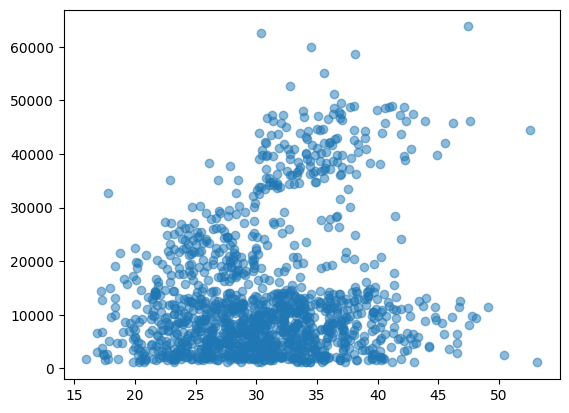

There is a weak overall relationship between bmi and charges (r = 0.20)


In [ ]:
plt.scatter(df['bmi'], df['charges'], alpha=0.5)
plt.show()
bmi_charges_corr = df['bmi'].corr(df['charges'])
print(f"There is a weak overall relationship between bmi and charges (r = {bmi_charges_corr:.2f})")

In [ ]:
median_charges_across_smoker = df.groupby('smoker')['charges'].median()
print(median_charges_across_smoker)
ratio = median_charges_across_smoker['yes'] / median_charges_across_smoker['no']
print(f"Smokers have much higher medical charges than non-smokers "
      f"(median {median_charges_across_smoker['yes']:,.0f} vs {median_charges_across_smoker['no']:,.0f}, about {ratio:.1f}x higher).")

smoker
no      7345.40530
yes    34456.34845
Name: charges, dtype: float64
Smokers have much higher medical charges than non-smokers (median 34,456 vs 7,345, about 4.7x higher).


In [ ]:
median_charges_across_sex = df.groupby('sex')['charges'].median()
median_charges_across_sex

,charges
sex,
female,9412.96250
male,9369.61575


In [ ]:
median_charges_across_children = df.groupby('children')['charges'].median()
median_charges_across_children

,charges
children,
0,9856.95190
1,8483.87015
2,9264.97915
3,10600.54830
4,11033.66170
5,8589.56505


In [ ]:
median_charges_across_region = df.groupby('region')['charges'].median()
median_charges_across_region

,charges
region,
northeast,10057.652025
northwest,8965.795750
southeast,9294.131950
southwest,8798.593000


In [ ]:
median_age_across_smoker = df.groupby('smoker')['age'].median()
median_age_across_smoker

,age
smoker,
no,40.0
yes,38.0


In [ ]:
median_bmi_across_smoker = df.groupby('smoker')['bmi'].median()
median_bmi_across_smoker

,bmi
smoker,
no,30.3525
yes,30.4475


## Deeper EDA
- How does smoking status affect the relationship between age and charges?
- How does smoking status affect the relationship between BMI and charges?
- Are there particular age groups with unusually high medical costs?
- Are there outliers in charges? If so, what characteristics do those customers have?
- Are there interactions between smoker, age, and bmi that appear to explain high charges?
- Which numerical features have the strongest correlation with charges?
- Can you identify a group of customers with exceptionally high medical costs? - What do they have in common?

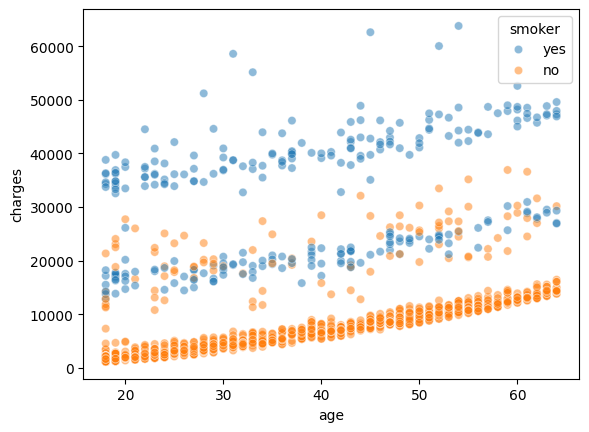

In [ ]:
sns.scatterplot(x='age',y='charges', hue='smoker', data=df, alpha=0.5)
plt.show()

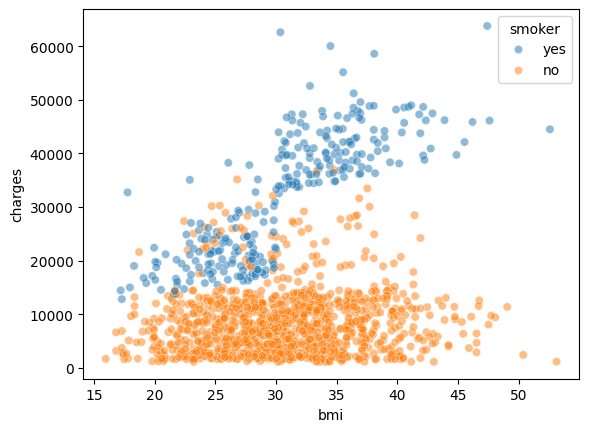

In [ ]:
sns.scatterplot(x='bmi',y='charges', hue='smoker', data=df, alpha=0.5)
plt.show()

/tmp/ipykernel_1106/3889500497.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_bins_charges = df.groupby('age_bins')['charges'].median()


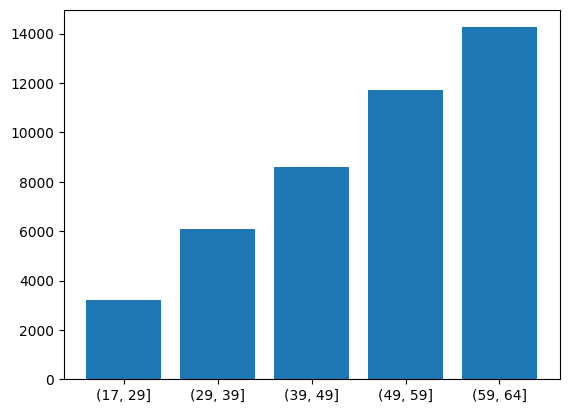

In [ ]:
bins = [17, 29, 39, 49, 59, 64]
age_bins = pd.cut(df['age'], bins=bins)
df['age_bins'] = age_bins
age_bins_charges = df.groupby('age_bins')['charges'].median()
plt.bar(age_bins_charges.index.astype(str), age_bins_charges)
plt.show()

In [ ]:
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['charges'] < lower) | (df['charges'] > upper)]
print(len(outliers))

139


In [ ]:
outliers.describe()

,age,bmi,children,charges
count,139.000000,139.000000,139.000000,139.000000
mean,41.079137,35.564604,1.187050,42103.947206
std,13.801420,4.434917,1.126546,5582.168107
min,18.000000,22.895000,0.000000,34617.840650
25%,30.000000,32.667500,0.000000,37786.149950
50%,43.000000,35.200000,1.000000,40974.164900
75%,52.500000,37.660000,2.000000,45786.706425
max,64.000000,52.580000,4.000000,63770.428010


In [ ]:
non_outliers = df[df['charges'].between(lower, upper)]
non_outliers.describe()

,age,bmi,children,charges
count,1199.000000,1199.000000,1199.000000,1199.000000
mean,38.989992,30.095200,1.084237,9927.753402
std,14.068040,6.010551,1.214304,7241.158309
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,25.800000,0.000000,4408.695900
50%,39.000000,29.735000,1.000000,8410.046850
75%,51.000000,33.820000,2.000000,12953.594600
max,64.000000,53.130000,5.000000,34472.841000


In [ ]:
print("for numerical features, age and bmi can have meaningful insights between outliers and non-outliers")

for numerical features, age and bmi can have meaningful insights between outliers and non-outliers


In [ ]:
for feature in outliers.columns:
  if feature in categorical_features:
    print(outliers[feature].value_counts(normalize=True) * 100)

sex
male      64.028777
female    35.971223
Name: proportion, dtype: float64
smoker
yes    97.841727
no      2.158273
Name: proportion, dtype: float64
region
southeast    41.007194
southwest    24.460432
northeast    20.143885
northwest    14.388489
Name: proportion, dtype: float64


In [ ]:
for feature in non_outliers.columns:
  if feature in categorical_features:
    print(non_outliers[feature].value_counts(normalize=True) * 100)

sex
female    51.042535
male      48.957465
Name: proportion, dtype: float64
smoker
no     88.490409
yes    11.509591
Name: proportion, dtype: float64
region
southeast    25.604671
northwest    25.437865
northeast    24.687239
southwest    24.270225
Name: proportion, dtype: float64


In [ ]:
print("for categorical features, all features have differ between outliers and non-outliers especially smoker")

for categorical features, all features have differ between outliers and non-outliers especially smoker


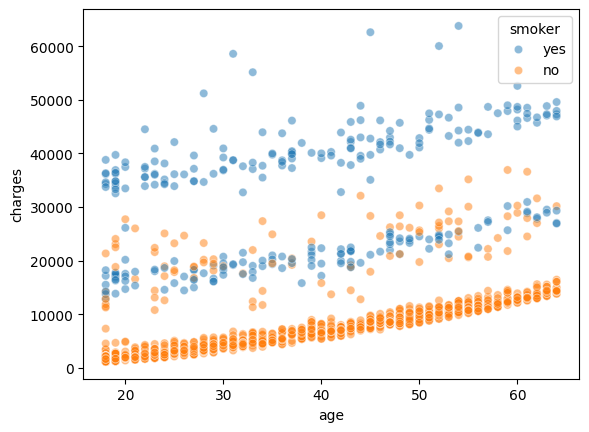

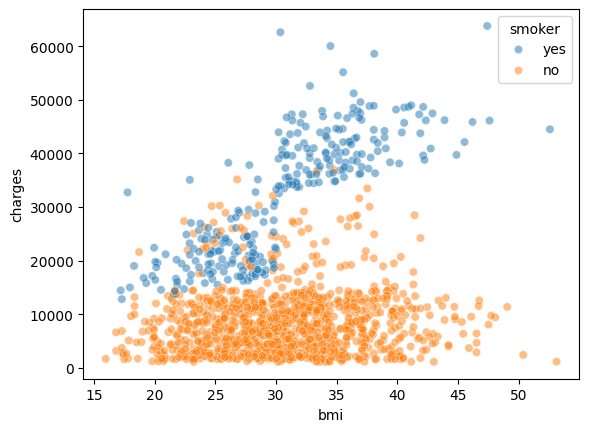

Yes. Smokers pay higher charges than non-smokers of the same age, and the gap stays roughly constant across ages, so age and smoking act mostly additively.
Yes. BMI interacts with smoking: among smokers, charges rise with BMI (especially above 30), while non-smokers' charges stay mostly flat regardless of BMI.


In [ ]:
#Are there interactions between smoker, age, and bmi that appear to explain high charges?
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.5)
plt.show()
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, alpha=0.5)
plt.show()
print("Yes. Smokers pay higher charges than non-smokers of the same age, and the gap stays roughly constant across ages, "
      "so age and smoking act mostly additively.")
print("Yes. BMI interacts with smoking: among smokers, charges rise with BMI (especially above 30), "
      "while non-smokers' charges stay mostly flat regardless of BMI.")

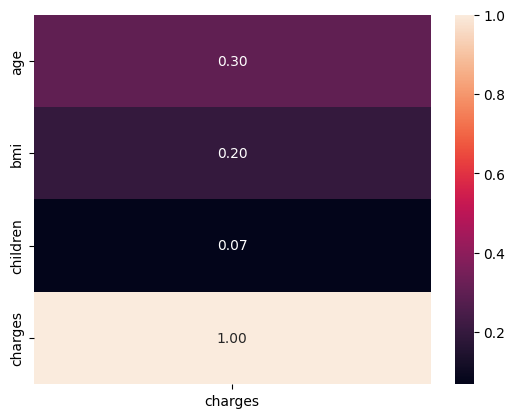

age have the strongest corr with charges


In [ ]:
numerical_features_charges_corr = df[numerical_features].corr()[['charges']]
sns.heatmap(numerical_features_charges_corr, annot=True, fmt='0.2f')
plt.show()
print('age have the strongest corr with charges')

In [ ]:
#Can you identify a group of customers with exceptionally high medical costs? - What do they have in common?
outliers.describe()

,age,bmi,children,charges
count,139.000000,139.000000,139.000000,139.000000
mean,41.079137,35.564604,1.187050,42103.947206
std,13.801420,4.434917,1.126546,5582.168107
min,18.000000,22.895000,0.000000,34617.840650
25%,30.000000,32.667500,0.000000,37786.149950
50%,43.000000,35.200000,1.000000,40974.164900
75%,52.500000,37.660000,2.000000,45786.706425
max,64.000000,52.580000,4.000000,63770.428010


In [ ]:
for feature in outliers.columns:
  if feature in categorical_features:
    print(outliers[feature].value_counts(normalize=True) * 100)

sex
male      64.028777
female    35.971223
Name: proportion, dtype: float64
smoker
yes    97.841727
no      2.158273
Name: proportion, dtype: float64
region
southeast    41.007194
southwest    24.460432
northeast    20.143885
northwest    14.388489
Name: proportion, dtype: float64


In [ ]:
print("""
Customers with exceptionally high charges (139 outliers, about 10%) mostly share:
- smoking status: 98% are smokers
- high BMI: median 35.2, and about 75% are 32.7 or above
Other traits are less consistent: 64% are male, 41% live in the southeast,
and they span all ages (18-64) with 0-4 children.
""")


Customers with exceptionally high charges (139 outliers, about 10%) mostly share:
- smoking status: 98% are smokers
- high BMI: median 35.2, and about 75% are 32.7 or above
Other traits are less consistent: 64% are male, 41% live in the southeast,
and they span all ages (18-64) with 0-4 children.



# clean data

In [ ]:
print(df.duplicated().sum())
print(len(df))
df = df.drop_duplicates()
print(df.duplicated().sum())
print(len(df))

1
1338
0
1337


# Import The Important Libraries Part2

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# Model Pipeline

In [ ]:
X = df.drop(columns=['age_bins', 'charges'])
y = df['charges']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1069, 6)
(1069,)
(268, 6)
(268,)


In [ ]:
numerical_features_for_model = [col for col in numerical_features if col != 'charges']
preprocessing = ColumnTransformer(
    transformers=[
        ('Scalar', StandardScaler(), numerical_features_for_model),
         ('Encoder', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

In [ ]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessing),
    ('model', 'passthrough')
])

In [ ]:
param_grid = [
    {
        'model': [LinearRegression()],
    },
     {
        'model': [DecisionTreeRegressor()],
        'model__max_depth':[2, 3, 4, 5, 6, 8, 10],
        'model__min_samples_leaf': [2, 5, 10, 20]
     },
    {
        'model': [RandomForestRegressor()],
        'model__n_estimators': [50, 100, 150, 200, 250, 300],
        'model__max_depth':[2, 3, 4, 5, 6, 8, 10],
        'model__min_samples_leaf': [2, 5, 10, 20]
    }]
grid = GridSearchCV(full_pipline, param_grid, cv=5, scoring='r2')

In [ ]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('Scalar',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'bmi',
                                                                          'children']),
                                                                        ('Encoder',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['sex',
                                                                          'smoker',
                                                                          'region'])])),
                                       ('model', 'passthrough')]),
             param_grid=[{'model': [LinearRegression()]},
                         {'model': [DecisionTreeRegressor()],
                          'model__max_depth': [2, 3, 4, 5, 6, 8, 10],
                          'model__min_samples_leaf': [2, 5, 10, 20]},
                         {'model': [RandomForestRegressor()],
                          'model__max_depth': [2, 3, 4, 5, 6, 8, 10],
                          'model__min_samples_leaf': [2, 5, 10, 20],
                          'model__n_estimators': [50, 100, 150, 200, 250,
                                                  300]}],
             scoring='r2')

In [ ]:
y_pred = grid.predict(X_test)
print(root_mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

4582.234734461259
2621.764939331697
0.8762333955336814


In [ ]:
grid.best_params_

{'model': RandomForestRegressor(),
 'model__max_depth': 4,
 'model__min_samples_leaf': 5,
 'model__n_estimators': 150}

In [ ]:
plt.scatter()

In [ ]:
scoring_model = pd.DataFrame({'score':grid.cv_results_['mean_test_score'],'model': grid.cv_results_['param_model']})
scoring_model['model'] = scoring_model['model'].apply(lambda a: type(a).__name__)

In [ ]:
scoring_model['model'].unique()

array(['LinearRegression', 'DecisionTreeRegressor',
       'RandomForestRegressor'], dtype=object)

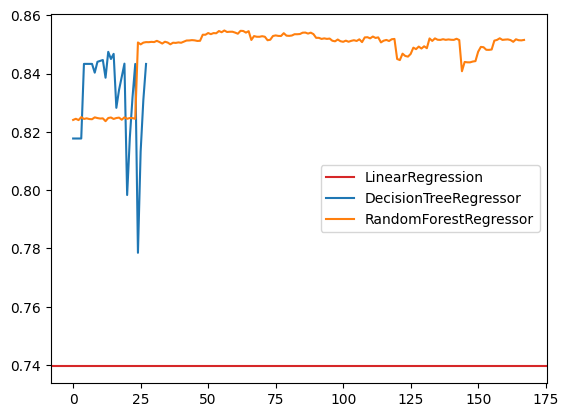

In [ ]:
for model in ['LinearRegression', 'DecisionTreeRegressor', 'RandomForestRegressor']:
  plot_model = scoring_model[scoring_model['model'] == model].reset_index(drop=True)
  if len(plot_model) == 1:
    plt.axhline(plot_model['score'][0], color='tab:red', label=model)
  else:
    plt.plot(plot_model['score'], label=model)
  plt.legend()
plt.show()

**reset_index()**

create new defualt index for the dataframe and convert the old index into new column in the data frame

**reset_index(drop=True)**

means:
- Create a new default index → 0, 1, 2, 3, ...
- Discard the old index → don't keep it as a column